In [15]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tkinter as tk

In [19]:
# Load the trajectory and topology files
#prmtop_file = input("Enter the path to the prmtop file: ")
#nc_file = input("Enter the path to the .nc file: ")

u = mda.Universe(prmtop_file, nc_file)
#ref = mda.Universe('/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/EFE_solv.prmtop','/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/EFE_solv.pdb')
len(u.trajectory)

ValueError: '' isn't a valid topology format, nor a coordinate format
   from which a topology can be minimally inferred.
   You can use 'Universe(topology, ..., topology_format=FORMAT)'
   to explicitly specify the format and
   override automatic detection. Known FORMATs are:
   dict_keys(['PSF', 'TOP', 'PRMTOP', 'PARM7', 'PDB', 'ENT', 'XPDB', 'PQR', 'GRO', 'CRD', 'PDBQT', 'DMS', 'TPR', 'MOL2', 'DATA', 'LAMMPSDUMP', 'XYZ', 'TXYZ', 'ARC', 'GMS', 'CONFIG', 'HISTORY', 'XML', 'MMTF', 'GSD', 'MINIMAL', 'ITP', 'PARMED', 'IN', 'FHIAIMS'])
   See https://docs.mdanalysis.org/documentation_pages/topology/init.html#supported-topology-formats
   For missing formats, raise an issue at 
   https://github.com/MDAnalysis/mdanalysis/issues

In [6]:
# Calculate RMSD
rmsd = rms.RMSD(u, u, ref_frame=0, select='backbone')
rmsd.run()

# Convert frames to time
time_step = 0.1  # time step in nanoseconds
time = np.arange(len(rmsd.rmsd)) * time_step

# Calculate average RMSD
average_rmsd = np.mean(rmsd.rmsd[:, 2])

# Create a DataFrame with time and RMSD values
rmsd_df = pd.DataFrame({
    'Time (ns)': time,
    'RMSD (Å)': rmsd.rmsd[:, 2]
})

In [7]:

# Print the DataFrame and average RMSD
print("RMSD DataFrame:")
print(rmsd_df)
print(f"\nAverage RMSD: {average_rmsd:.2f} Å")

RMSD DataFrame:
      Time (ns)      RMSD (Å)
0           0.0  2.930051e-07
1           0.1  8.392854e-01
2           0.2  8.311177e-01
3           0.3  9.317016e-01
4           0.4  8.391863e-01
...         ...           ...
9995      999.5  2.016767e+00
9996      999.6  2.123876e+00
9997      999.7  2.039173e+00
9998      999.8  2.164509e+00
9999      999.9  2.072564e+00

[10000 rows x 2 columns]

Average RMSD: 1.67 Å


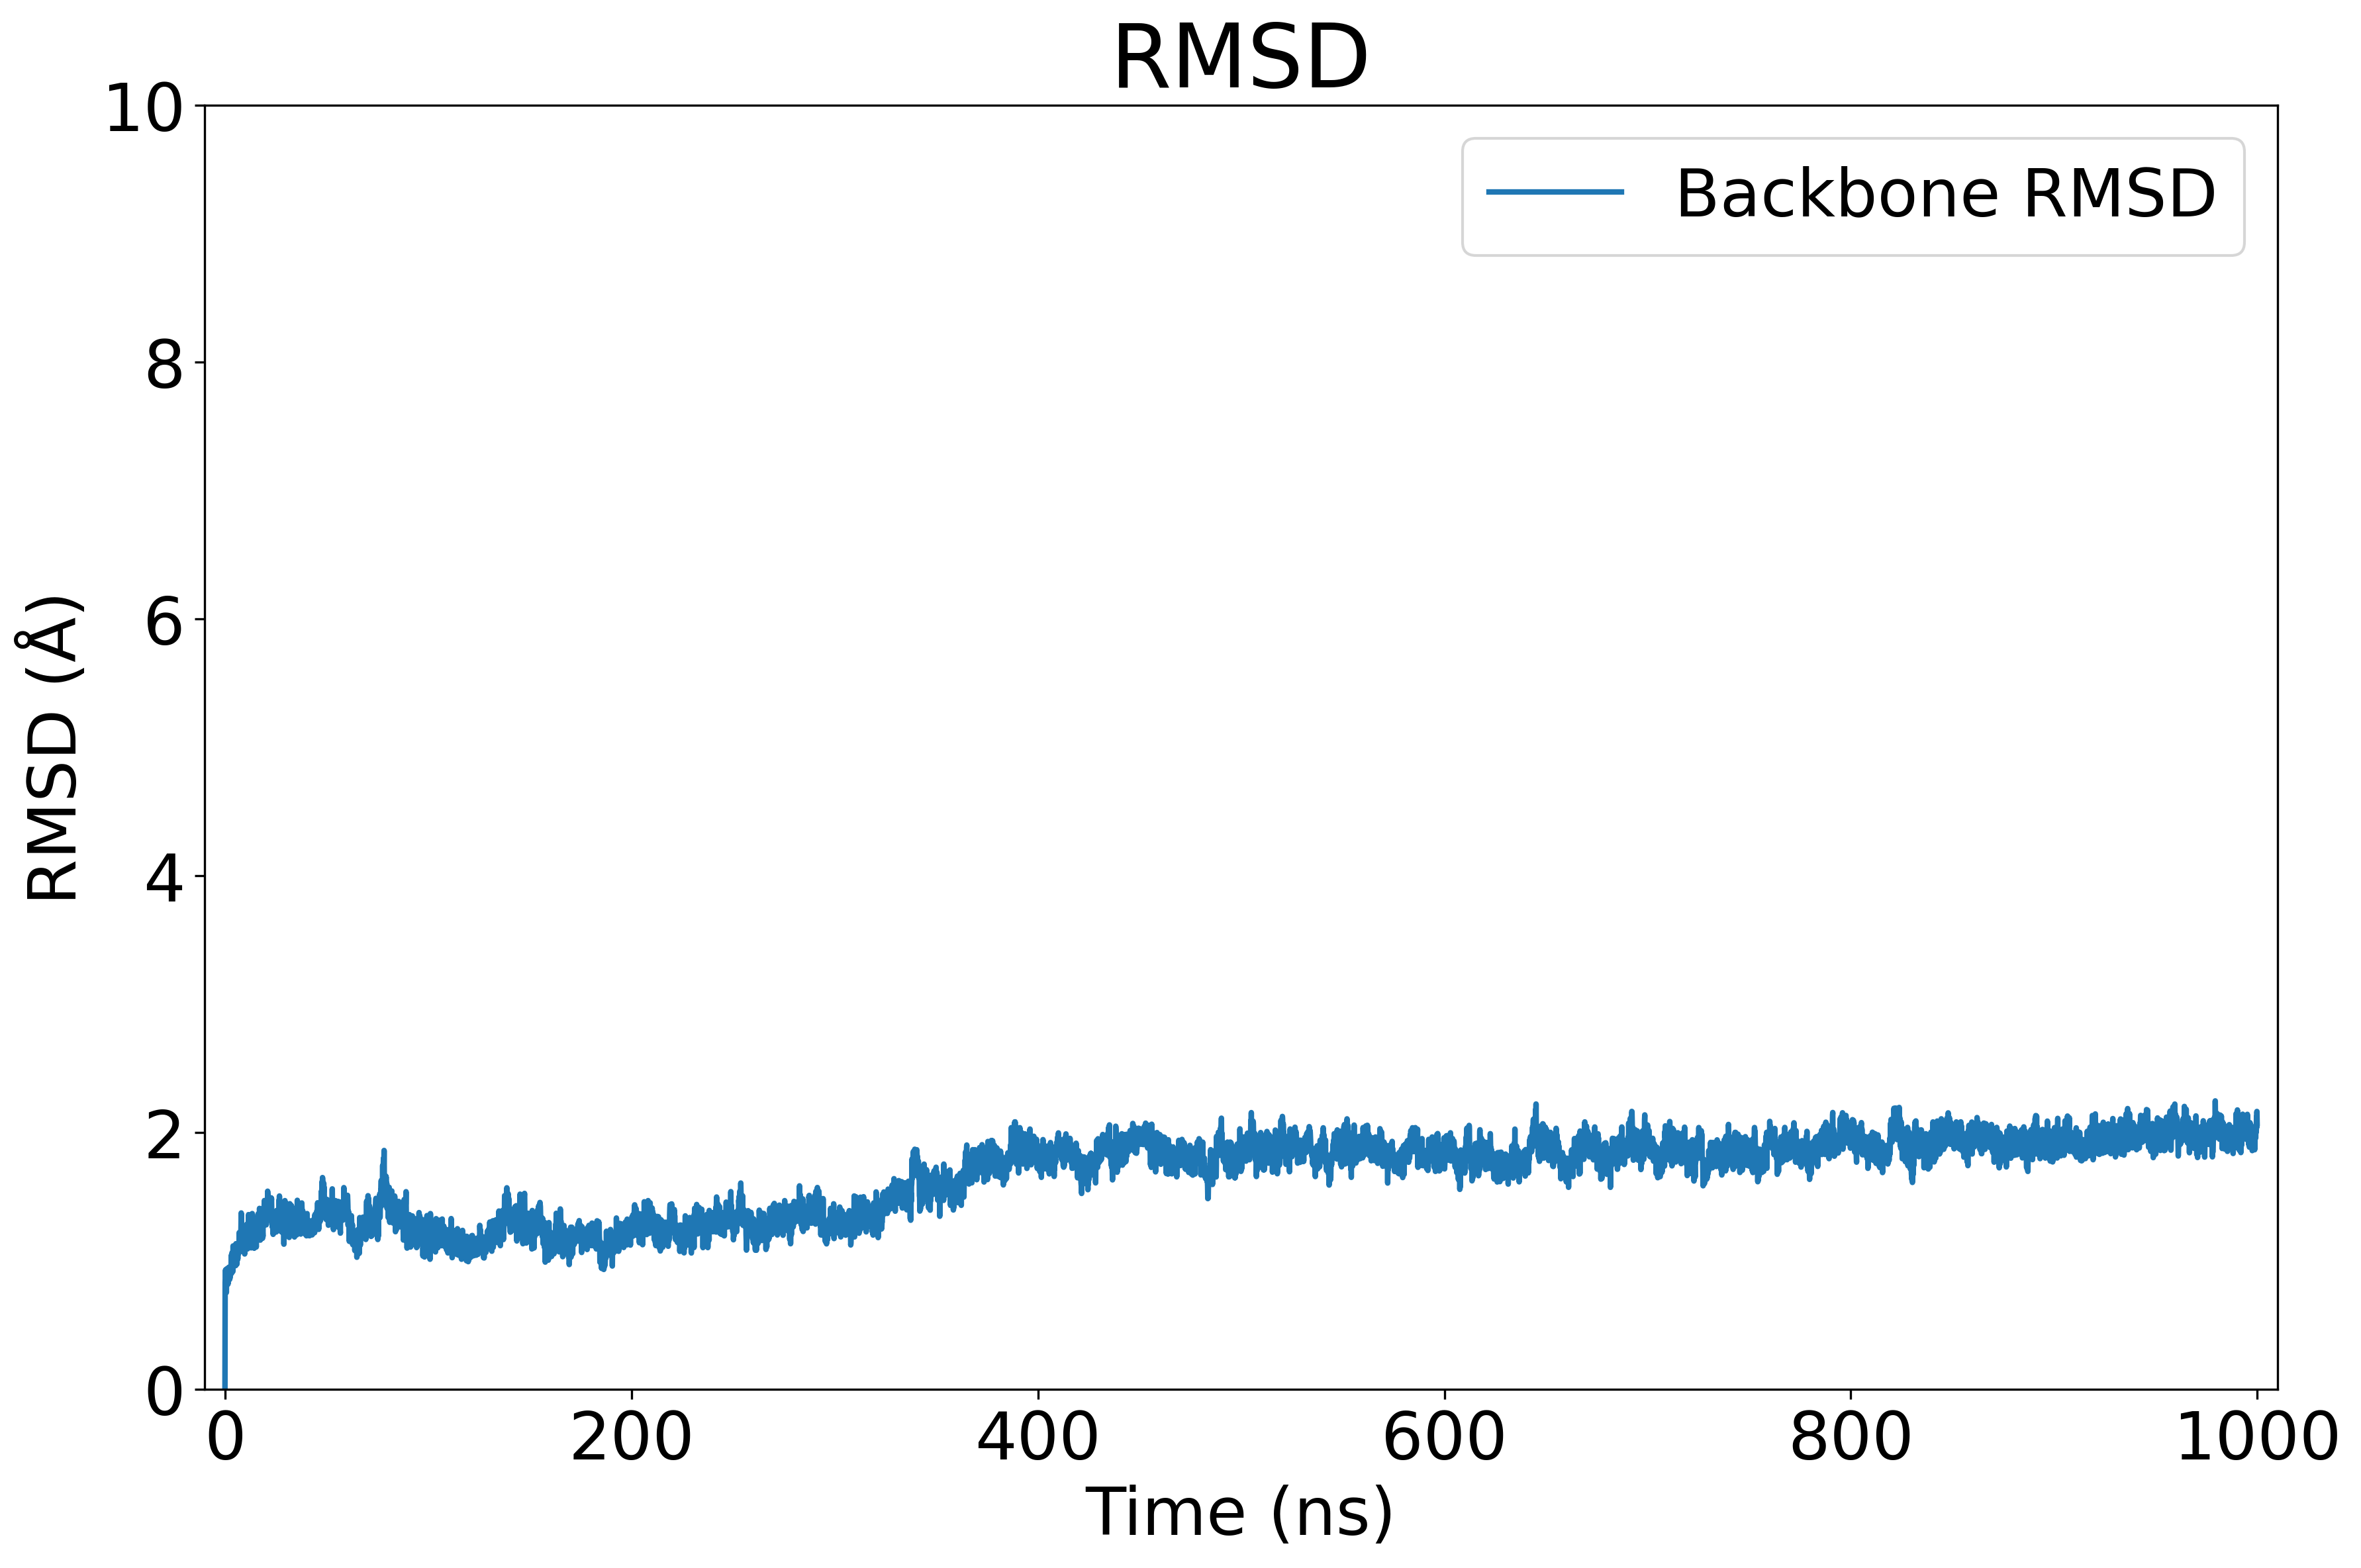

In [13]:
# Configure Matplotlib to use Arial font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

# Plot RMSD with high quality settings
plt.figure(figsize=(12, 8), dpi=300)  # Set figure size and resolution
plt.plot(time, rmsd.rmsd[:, 2], label='Backbone RMSD', linewidth=2)
plt.xlabel('Time (ns)', fontsize=24)
plt.ylabel('RMSD (Å)', fontsize=24)
plt.ylim(0, 10)
plt.xlim(-10,1010)
plt.title('RMSD', fontsize=32)
plt.legend(fontsize=24)
plt.grid(False)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate RMSF
rmsf = rms.RMSF(u.select_atoms('name CA')).run()
rmsf_values = rmsf.rmsf

In [ ]:
# Configure Matplotlib to use Arial font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

# Plot RMSF with high quality settings
plt.figure(figsize=(12, 8), dpi=300)  # Set figure size and resolution
plt.plot(rmsf.resids, rmsf_values, label='RMSF', linewidth=2)
plt.xlabel('Residue', fontsize=14)
plt.ylabel('RMSF (Å)', fontsize=14)
plt.title('RMSF', fontsize=16)
plt.legend(fontsize=12)
plt.ylim(0, 10)
plt.grid(False)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('rmsf_plot.png', dpi=300)  # Save the plot as a high-quality picture
plt.show()

NameError: name 'plt' is not defined